In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

INPUT_LENGTH = 24
OUTPUT_LENGTH = 20

In [60]:
df_train_init = pd.read_csv("train.csv", sep=';', parse_dates=['date'], index_col='date')
df_test_init = pd.read_csv("test.csv", sep=';', parse_dates=['date'], index_col='date')

df_train_monthly = df_train_init.interpolate(method='time').resample('ME').mean()
df_test_monthly = df_test_init.interpolate(method='time').resample('ME').mean()

In [61]:
def create_sequences_ml(data, seq_length, target_col, output_length=1):
    xs = []
    ys = []
    for i in range(len(data) - seq_length - output_length + 1):
        x = data[target_col].iloc[i:(i + seq_length)].values
        y = data[target_col].iloc[(i + seq_length):(i + seq_length + output_length)].values
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

nb_valid = 100

df_train = df_train_monthly[:-nb_valid].copy()
df_valid = df_train_monthly[-nb_valid:].copy()
df_test = df_test_monthly.copy()

scaler = MinMaxScaler()
df_train['target'] = scaler.fit_transform(df_train[['target']])
df_valid['target'] = scaler.transform(df_valid[['target']])
df_test['target'] = scaler.transform(df_test[['target']])
print("Test shape df :", df_test.shape)

# Séquences 2D adaptées pour XGBoost, LightGBM et Random Forest
trainX, trainY = create_sequences_ml(df_train, seq_length=INPUT_LENGTH, target_col='target', output_length=OUTPUT_LENGTH)
validX, validY = create_sequences_ml(df_valid, seq_length=INPUT_LENGTH, target_col='target', output_length=OUTPUT_LENGTH)
testX, testY = create_sequences_ml(df_test, seq_length=INPUT_LENGTH, target_col='target', output_length=OUTPUT_LENGTH)

print("Train shape :", trainX.shape, trainY.shape)
print("Validation shape :", validX.shape, validY.shape)
print("Test shape :", testX.shape, testY.shape)

Test shape df : (54, 1)
Train shape : (145, 24) (145, 20)
Validation shape : (57, 24) (57, 20)
Test shape : (11, 24) (11, 20)


In [70]:
# MultiOutputRegressor permet de faire du sequence-to-sequence (prédire 24 mois d'un coup) avec XGBoost et LightGBM
models = {
    "Random Forest": RandomForestRegressor(n_estimators=400, random_state=80),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    "LightGBM": MultiOutputRegressor(LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1))
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(trainX, trainY)
    
    valid_preds = model.predict(validX)
    mse = mean_squared_error(validY, valid_preds)
    print(f"{name} Validation MSE: {mse:.4f}\n")
    
    trained_models[name] = model

Training Random Forest...
Random Forest Validation MSE: 0.0292

Training XGBoost...
XGBoost Validation MSE: 0.0436

Training LightGBM...
LightGBM Validation MSE: 0.0410



c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_IA\final lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_IA\final lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_IA\final lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_IA\final lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_I

c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_IA\final lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_IA\final lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_IA\final lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_IA\final lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kylia\OneDrive\Bureau\Cours\Apprentissage_I

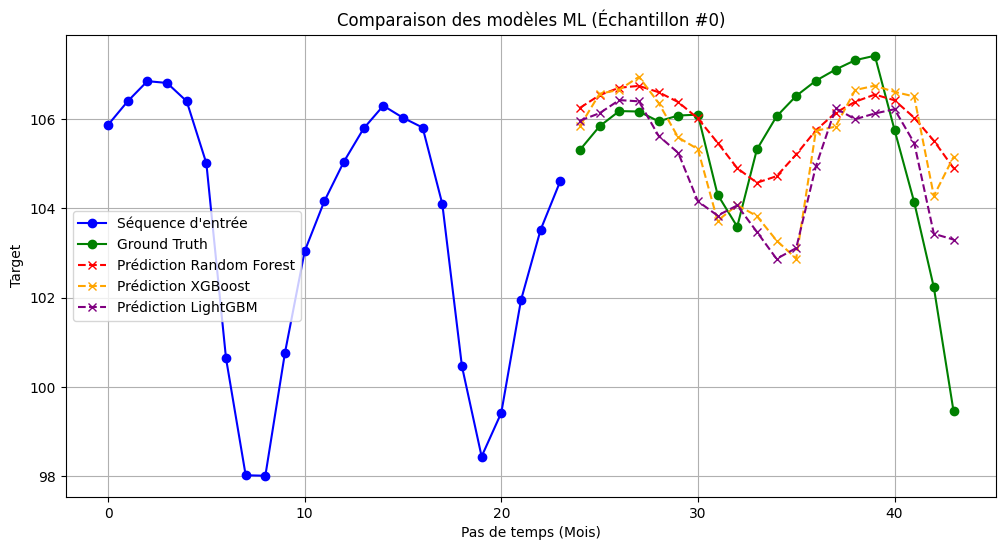

In [71]:
def plot_ml_prediction(models_dict, testX, testY, scaler=None, sample_idx=0):
	input_seq = testX[sample_idx]
	true_target = testY[sample_idx]
		
	if scaler is not None:
		input_seq_plot = scaler.inverse_transform(input_seq.reshape(-1, 1)).flatten()
		true_target_plot = scaler.inverse_transform(true_target.reshape(-1, 1)).flatten()
	else:
		input_seq_plot = input_seq
		true_target_plot = true_target
		
	time_input = np.arange(len(input_seq_plot))
	time_target = np.arange(len(input_seq_plot), len(input_seq_plot) + len(true_target_plot))
		
	plt.figure(figsize=(12, 6))
	plt.plot(time_input, input_seq_plot, label='Séquence d\'entrée', color='blue', marker='o')
	plt.plot(time_target, true_target_plot, label='Ground Truth', color='green', marker='o')
		
	colors = ['red', 'orange', 'purple']
	for (name, model), color in zip(models_dict.items(), colors):
		pred_target = model.predict([input_seq])[0]
		if scaler is not None:
			pred_target = scaler.inverse_transform(pred_target.reshape(-1, 1)).flatten()
		plt.plot(time_target, pred_target, label=f'Prédiction {name}', color=color, linestyle='--', marker='x')

	plt.title(f'Comparaison des modèles ML (Échantillon #{sample_idx})')
	plt.xlabel('Pas de temps (Mois)')
	plt.ylabel('Target')
	plt.legend()
	plt.grid(True)
	plt.show()

plot_ml_prediction(trained_models, testX, testY, scaler=scaler, sample_idx=0)